In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/healthcare_dataset.csv")

In [3]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
df.shape

(55500, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [6]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [7]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [8]:
df['Length of Stay'] = (
    df['Discharge Date'] - df['Date of Admission']
).dt.days

In [9]:
df[['Date of Admission', 'Discharge Date', 'Length of Stay']].head()

,Date of Admission,Discharge Date,Length of Stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


In [10]:
df['Length of Stay'].mean()

15.50900900900901

In [11]:
df['Medical Condition'].value_counts()

Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: Medical Condition, dtype: int64

In [12]:
billing_by_condition = (
    df.groupby('Medical Condition')['Billing Amount']
      .mean()
      .sort_values(ascending=False)
)

billing_by_condition

Medical Condition
Obesity         25805.971259
Diabetes        25638.405577
Asthma          25635.249359
Arthritis       25497.327056
Hypertension    25497.095761
Cancer          25161.792707
Name: Billing Amount, dtype: float64

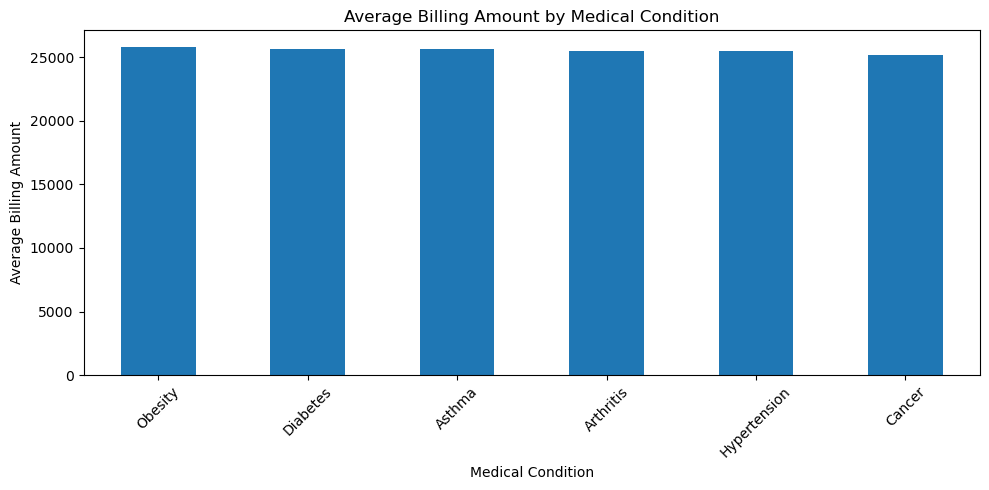

In [13]:
billing_by_condition.plot(kind='bar', figsize=(10,5))

plt.title('Average Billing Amount by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Average Billing Amount')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [14]:
df['Admission Type'].value_counts()

Elective     18655
Urgent       18576
Emergency    18269
Name: Admission Type, dtype: int64

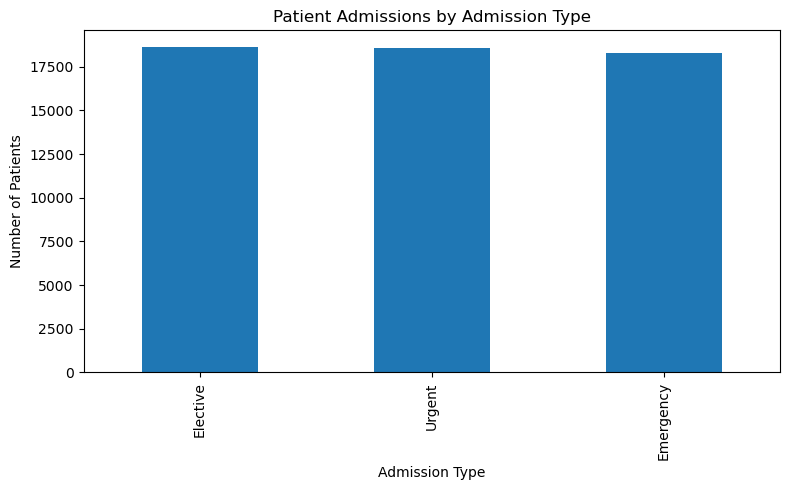

In [15]:
admission_counts = df['Admission Type'].value_counts()

admission_counts.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Patient Admissions by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Number of Patients')

plt.tight_layout()

plt.show()

In [16]:
df.groupby('Admission Type')['Length of Stay'].mean()

Admission Type
Elective     15.525328
Emergency    15.595052
Urgent       15.408000
Name: Length of Stay, dtype: float64

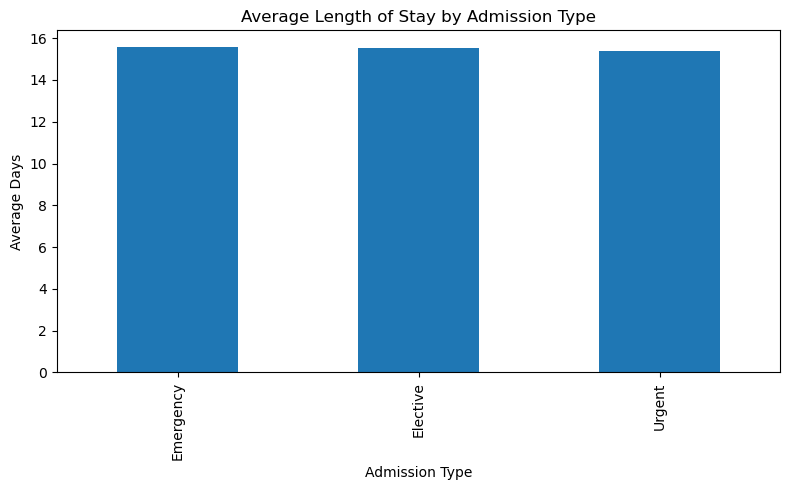

In [18]:
los_by_admission = (
    df.groupby('Admission Type')['Length of Stay']
      .mean()
      .sort_values(ascending=False)
)

los_by_admission.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Length of Stay by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Average Days')

plt.tight_layout()

plt.show()

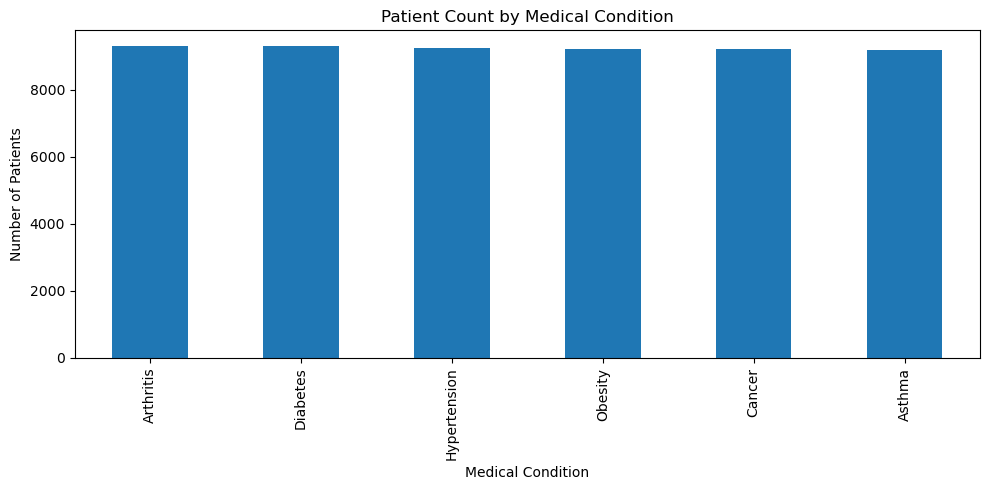

In [19]:
condition_counts = df['Medical Condition'].value_counts()

condition_counts.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Patient Count by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.show()

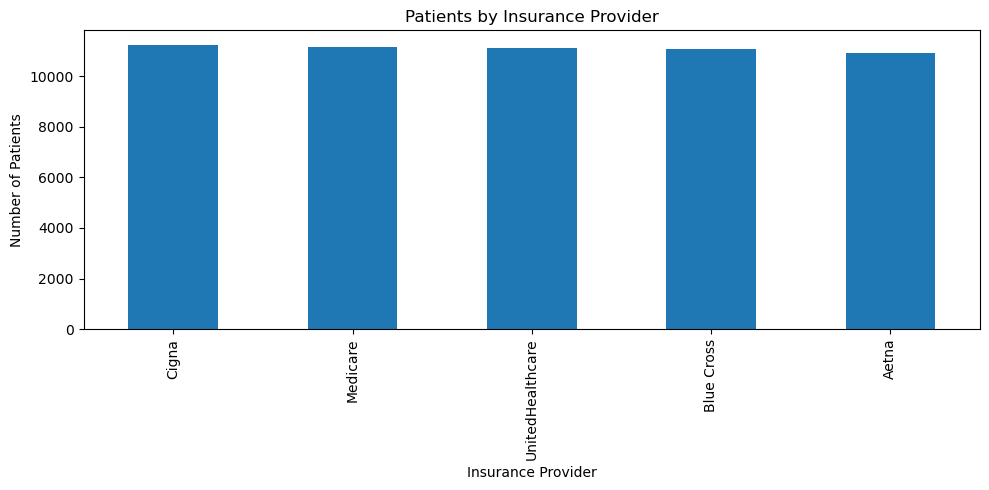

In [20]:
insurance_counts = df['Insurance Provider'].value_counts()

insurance_counts.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Patients by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.show()

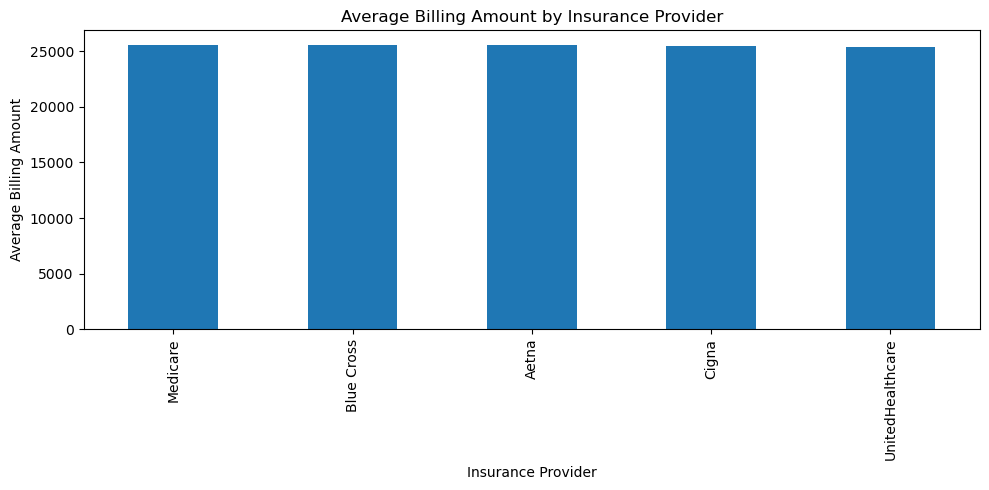

In [21]:
insurance_billing = (
    df.groupby('Insurance Provider')['Billing Amount']
      .mean()
      .sort_values(ascending=False)
)

insurance_billing.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Average Billing Amount by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Average Billing Amount')

plt.tight_layout()
plt.show()

In [23]:
df['Age'].describe()

count    55500.000000
mean        51.539459
std         19.602454
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64

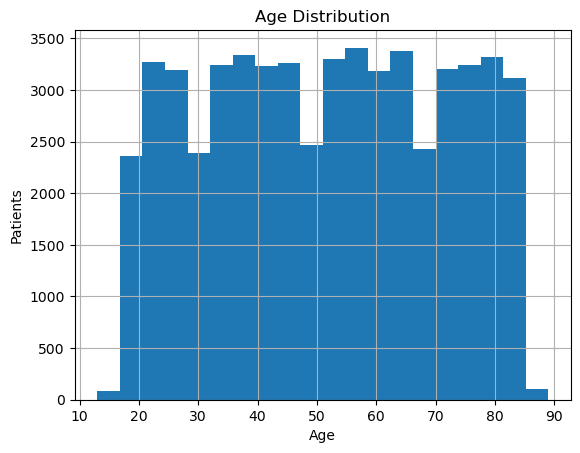

In [24]:
df['Age'].hist(bins=20)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Patients')

plt.show()

Key Findings

- No missing values were identified in the dataset.
- Admission types were distributed relatively evenly.
- Average billing amounts showed limited variation across medical conditions.
- Average length of stay remained consistent across admission categories.
- The dataset appears highly balanced, limiting strong segmentation insights.

In [27]:
df.to_csv("../data/healthcare_cleaned.csv", index=False)